# Generation and post-analysis in a real dataset 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tableone import TableOne
import torch
from sksurv.nonparametric import kaplan_meier_estimator
import os
import sys
from pathlib import Path
module_path = Path.cwd().parent / 'utils'
sys.path.append(str(module_path))
import data_processing, visualization, metrics

module_path = Path.cwd().parent / 'execute'
sys.path.append(str(module_path))

from synthcity.metrics.plots import plot_tsne
from synthcity.metrics.eval import Metrics
from synthcity.metrics.scores import ScoreEvaluator
from synthcity.plugins.core.dataloader import SurvivalAnalysisDataLoader
from synthcity.utils.reproducibility import clear_cache, enable_reproducible_results

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

c:\Users\smolanoq\AppData\Local\miniconda3\envs\no_synthcity\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[KeOps] Warning : No C++ compiler found. Define CXX environment variable or install g++.
[KeOps] Warning : No C++ compiler found. You need to either define the CXX environment variable pointing to a valid compiler, or ensure that 'g++' is installed and in your PATH.
[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.
[KeOps] Warning : No C++ compiler found. You need to either define the CXX environment variable pointing to a valid compiler, or ensure that 'g++' is installed and in your PATH.
[KeOps] Warning : No C++ compiler available to check for OpenMP support.
[KeOps] Warning : OpenMP support is not available. Disabling OpenMP.


## 1. Original data loading, analysis and visualization

### 1.1. Experiment setting - links to data

In [3]:
dataset_name = "ACTG320"
current_path = os.getcwd()  # Get current working directory
parent_path = os.path.dirname(current_path)
data_file_control= parent_path + "/dataset/" + dataset_name + "/data_control.csv"
feat_types_file_control = parent_path + "/dataset/" + dataset_name + "/data_types_control.csv"
data_file_treated= parent_path + "/dataset/" + dataset_name + "/data_treated.csv"
feat_types_file_treated= parent_path + "/dataset/" + dataset_name + "/data_types_treated.csv"

# If the dataset has no missing data, leave the "miss_file" variable empty
miss_file = ""
true_miss_file = None

### 1.2. Loading, feature analysis, and visualization of original data: control vs treated group

In [4]:
control_fnames = ['time', 'censor'] + pd.read_csv(feat_types_file_control)["name"].to_list()[1:]
control = pd.read_csv(data_file_control, header=None, names=control_fnames)
print(control.head())

   time  censor  strat2  sex  raceth  ivdrug  karnof    cd4  priorzdv  age
0   189       0       1    0       1       0     100  169.0      39.0   34
1   287       0       1    1       2       0      90  149.5      15.0   34
2   199       0       1    0       1       0      90   46.0      53.0   48
3   270       0       1    0       2       0     100   54.5       6.0   51
4   276       0       1    0       1       0     100   95.0       7.0   34


In [5]:
# Load and transform control data
data_init_control_encoded, feat_types_dict, miss_mask_control, true_miss_mask_control, _ = data_processing.read_data(data_file_control, 
                                                                                                             feat_types_file_control, 
                                                                                                             miss_file, true_miss_file)

In [6]:
# Load and transform control data
df_init_control_encoded, feat_types_dict, miss_mask_control, true_miss_mask_control, _, dict_cat_map_control = data_processing.read_data(data_file_control, feat_types_file_control, miss_file, true_miss_file,
                                                                                                                                         return_cat_mapping=True)
data_init_control_encoded = torch.from_numpy(df_init_control_encoded.values)
data_init_control = data_processing.discrete_variables_transformation(data_init_control_encoded, feat_types_dict)

# Load and transform treated data
df_init_treated_encoded, _, _, _, _, dict_cat_map_treated = data_processing.read_data(data_file_treated, feat_types_file_treated, miss_file, true_miss_file,
                                                                                      return_cat_mapping=True)
data_init_treated_encoded = torch.from_numpy(df_init_treated_encoded.values)
data_init_treated = data_processing.discrete_variables_transformation(data_init_treated_encoded, feat_types_dict)

In [14]:
# Format data in dataframe
df_init_treated = pd.DataFrame(data_init_treated.numpy(), columns=control_fnames)
df_init_control = pd.DataFrame(data_init_control.numpy(), columns=control_fnames)

# Update the data
df_init_treated["treatment"] = 1
df_init_control["treatment"] = 0
df_init = pd.concat([df_init_control, df_init_treated], ignore_index=True)

In [15]:
continuous = [row['name'] for row in feat_types_dict if row['type'] in ['pos', 'real']]
categorical = [row['name'] for row in feat_types_dict if row['type'] in ['cat']]

## 2. Model training and data generation for different ε levels

In [ ]:
#We use the piecewise variant as a default.
for i in range(len(feat_types_dict)):
    if feat_types_dict[i]['name'] == "survcens":
        feat_types_dict[i]["type"] = 'surv_weibull'

{'HI-VAE_weibull': {'lr': 0.005,
  'batch_size': 92,
  'z_dim': 40,
  'y_dim': 30,
  's_dim': 4},
 'HI-VAE_piecewise': {'lr': 0.005,
  'batch_size': 69,
  'z_dim': 20,
  'y_dim': 30,
  's_dim': 18,
  'n_layers_surv_piecewise': 1,
  'n_intervals': 20}}

### 2.1. Whole dataset

In [ ]:
import json
name_config_1 = f"best_params_traincontrol_{dataset_name}_aug_Ncontrol3%3"
name_config_2 = "ntrials150_DetectXGB"

generators_sel = ["HI-VAE_weibull", "HI-VAE_piecewise", "HI-VAE_weibull_DP", "HI-VAE_piecewise_DP"]

best_params_dict = {}
for generator_name in generators_sel:
    best_param_file = ""
    if "DP" not in generator_name:
        # best_param_file = [item for item in best_param_files if generator_name in item][0]
        for f in os.listdir(parent_path + "/dataset/" + dataset_name + "/optuna_results"):
            if (f.endswith(generator_name + '.json') & (name_config_1 in f) & (name_config_2 in f)):
                best_param_file = f
        with open(parent_path + "/dataset/" + dataset_name + "/optuna_results/" + best_param_file, "r") as f:
            best_params_dict[generator_name] = json.load(f)
    else:
        dict_params_dp = {}
        for f in os.listdir(parent_path + "/dataset/" + dataset_name + "/optuna_results"):
            if (f.endswith(generator_name + '.json') & (name_config_1 in f) & (name_config_2 in f)):
                for eps in [1, 3, 5, 7, 10]:
                    best_param_file = ""
                    if (f"DP_eps_{eps}" in f):
                        best_param_file = f
                        with open(parent_path + "/dataset/" + dataset_name + "/optuna_results/" + best_param_file, "r") as f:
                            dict_params_dp[eps] = json.load(f)
        best_params_dict[generator_name] = dict_params_dp


In [ ]:
import surv_hivae # our model

n_generated_dataset = 200

dict_eps_generated_data = {}
for eps in [1.0, 3.0, 5.0, 7.0, 10.0]:
    data_gen_control_eps = surv_hivae.run(df_init_control_encoded,
                                            miss_mask_control, 
                                            true_miss_mask_control,
                                            feat_types_dict,
                                            n_generated_dataset,
                                            seed=1,
                                            apply_rounding=True,
                                            params=best_params_dict['HI-VAE_weibull_DP'][round(eps)],
                                            differential_privacy=True,
                                            target_epsilon=eps)
    list_df_gen_control = []
    for j in range(n_generated_dataset):
        df_gen_control_j = pd.DataFrame(data_gen_control_eps[j].numpy(), columns=control_fnames)
        df_gen_control_j['treatment'] = 0
        list_df_gen_control.append(df_gen_control_j)
    list_df_gen_control_recoded = [
        data_processing.decode_categoricals(df, dict_cat_map_control)
        for df in list_df_gen_control]
    dict_eps_generated_data[eps] = list_df_gen_control_recoded


Epoch: [ 0]  time: 0.7729, ELBO_train: -27.11168257, KL_z: 6.49939545, KL_s: 0.02860570, reconstruction loss: -20.58368143
Epoch: [100]  time: 54.6628, ELBO_train: -28.89607938, KL_z: 8.02296384, KL_s: 0.06989097, reconstruction loss: -20.80322457
Epoch: [200]  time: 98.3861, ELBO_train: -35.24501610, KL_z: 10.32567549, KL_s: 0.09308642, reconstruction loss: -24.82625420
Epoch: [300]  time: 131.8011, ELBO_train: -177.06944402, KL_z: 11.99112415, KL_s: 0.15581721, reconstruction loss: -164.92250266
Epoch: [400]  time: 165.8447, ELBO_train: -1980.98870850, KL_z: 14.59047890, KL_s: 0.17646967, reconstruction loss: -1966.22175993
Epoch: [500]  time: 199.6650, ELBO_train: -670477.96889242, KL_z: 16.26750644, KL_s: 0.23335492, reconstruction loss: -670461.46803105
Epoch: [600]  time: 233.1611, ELBO_train: -10132.67265956, KL_z: 19.65349452, KL_s: 0.30837062, reconstruction loss: -10112.71079442
Epoch: [700]  time: 265.9423, ELBO_train: -275435.44953918, KL_z: 20.40823936, KL_s: 0.33674139, r

In [ ]:
# Non DP version
data_gen_control = surv_hivae.run(df_init_control_encoded,
                                  miss_mask_control, 
                                  true_miss_mask_control,
                                  feat_types_dict,
                                  n_generated_dataset,
                                  seed=1,
                                  apply_rounding=True,
                                  params=best_params_dict['HI-VAE_weibull'],
                                  differential_privacy=False)
list_df_gen_control = []
for j in range(n_generated_dataset):
    df_gen_control_j = pd.DataFrame(data_gen_control_eps[j].numpy(), columns=control_fnames)
    df_gen_control_j['treatment'] = 0
    list_df_gen_control.append(df_gen_control_j)
list_df_gen_control_recoded = [
    data_processing.decode_categoricals(df, dict_cat_map_control)
    for df in list_df_gen_control]
dict_eps_generated_data['No privacy'] = list_df_gen_control_recoded

Epoch: [ 0]  time: 0.2350, ELBO_train: -24.21410561, KL_z: 4.76292010, KL_s: 0.02897014, reconstruction loss: -19.42221536
Epoch: [100]  time: 15.6410, ELBO_train: -16.73820432, KL_z: 0.65999543, KL_s: 0.73202244, reconstruction loss: -15.34618645
Epoch: [200]  time: 28.2705, ELBO_train: -17.30945142, KL_z: 0.94219807, KL_s: 0.13285393, reconstruction loss: -16.23439942
Epoch: [300]  time: 39.9101, ELBO_train: -17.06299432, KL_z: 1.42371434, KL_s: 0.01328232, reconstruction loss: -15.62599766
Epoch: [400]  time: 55.2817, ELBO_train: -16.98873234, KL_z: 1.64888942, KL_s: 0.01459774, reconstruction loss: -15.32524518
Epoch: [500]  time: 74.6601, ELBO_train: -17.02161058, KL_z: 1.76162352, KL_s: 0.00823380, reconstruction loss: -15.25175326
Epoch: [600]  time: 94.5341, ELBO_train: -16.91538556, KL_z: 1.87011021, KL_s: 0.01210452, reconstruction loss: -15.03317083
Epoch: [700]  time: 113.9365, ELBO_train: -16.96059227, KL_z: 2.04098554, KL_s: 0.01430578, reconstruction loss: -14.90530094
E

### 2.2. 67% of the dataset

In [ ]:
import json
name_config_1 = f"best_params_traincontrol_{dataset_name}_aug_Ncontrol2%3"
name_config_2 = "ntrials150_DetectXGB"

generators_sel = ["HI-VAE_weibull", "HI-VAE_piecewise", "HI-VAE_weibull_DP", "HI-VAE_piecewise_DP"]

best_params_dict = {}
for generator_name in generators_sel:
    best_param_file = ""
    if "DP" not in generator_name:
        # best_param_file = [item for item in best_param_files if generator_name in item][0]
        for f in os.listdir(parent_path + "/dataset/" + dataset_name + "/optuna_results"):
            if (f.endswith(generator_name + '.json') & (name_config_1 in f) & (name_config_2 in f)):
                best_param_file = f
        with open(parent_path + "/dataset/" + dataset_name + "/optuna_results/" + best_param_file, "r") as f:
            best_params_dict[generator_name] = json.load(f)
    else:
        dict_params_dp = {}
        for f in os.listdir(parent_path + "/dataset/" + dataset_name + "/optuna_results"):
            if (f.endswith(generator_name + '.json') & (name_config_1 in f) & (name_config_2 in f)):
                for eps in [1, 3, 5, 7, 10]:
                    best_param_file = ""
                    if (f"DP_eps_{eps}" in f):
                        best_param_file = f
                        with open(parent_path + "/dataset/" + dataset_name + "/optuna_results/" + best_param_file, "r") as f:
                            dict_params_dp[eps] = json.load(f)
        best_params_dict[generator_name] = dict_params_dp


In [25]:
# In order to run a membership inference attack on real data, we need to decompose the initial set in a train vs holdout set.
list_indexes_train = list(np.random.choice(len(df_init_control), size=int(2/3 * len(df_init_control)), replace=False))

df_init_control_train = df_init_control[df_init_control.index.isin(list_indexes_train)].reset_index(drop=True)
df_init_control_holdout = df_init_control[~df_init_control.index.isin(list_indexes_train)].reset_index(drop=True)

df_init_control_encoded_train = df_init_control_encoded[df_init_control_encoded.index.isin(list_indexes_train)].reset_index(drop=True)

In [ ]:
import surv_hivae # our model

dict_eps_generated_data_aug = {}
for eps in [1.0, 3.0, 5.0, 7.0, 10.0]:
    data_gen_control_eps = surv_hivae.run(df_init_control_encoded_train,
                                            miss_mask_control[list_indexes_train], 
                                            true_miss_mask_control[list_indexes_train],
                                            feat_types_dict,
                                            n_generated_dataset,
                                            seed=1,
                                            apply_rounding=True,
                                            params=best_params_dict['HI-VAE_weibull_DP'][round(eps)],
                                            differential_privacy=True,
                                            target_epsilon=eps)
    list_df_gen_control = []
    for j in range(n_generated_dataset):
        df_gen_control_j = pd.DataFrame(data_gen_control_eps[j].numpy(), columns=control_fnames)
        df_gen_control_j['treatment'] = 0
        list_df_gen_control.append(df_gen_control_j)
    list_df_gen_control_recoded = [
        data_processing.decode_categoricals(df, dict_cat_map_control)
        for df in list_df_gen_control]
    dict_eps_generated_data_aug[eps] = list_df_gen_control_recoded


Epoch: [ 0]  time: 0.2775, ELBO_train: -27.24719048, KL_z: 6.58285260, KL_s: 0.03065463, reconstruction loss: -20.63368325
Epoch: [100]  time: 15.0216, ELBO_train: -29.26810837, KL_z: 7.77395928, KL_s: 0.05028711, reconstruction loss: -21.44386198
Epoch: [200]  time: 28.3066, ELBO_train: -32.03198862, KL_z: 9.83339691, KL_s: 0.08574321, reconstruction loss: -22.11284849
Epoch: [300]  time: 42.4058, ELBO_train: -36.13140965, KL_z: 11.02423096, KL_s: 0.09994322, reconstruction loss: -25.00723547
Epoch: [400]  time: 56.3814, ELBO_train: -179.37784576, KL_z: 12.51880622, KL_s: 0.12236106, reconstruction loss: -166.73667848
Epoch: [500]  time: 70.9150, ELBO_train: -199.54920197, KL_z: 14.24838638, KL_s: 0.21451857, reconstruction loss: -185.08629701
Epoch: [600]  time: 82.9159, ELBO_train: -513.57629776, KL_z: 16.39056730, KL_s: 0.21276817, reconstruction loss: -496.97296229
Epoch: [700]  time: 95.2285, ELBO_train: -196.36091995, KL_z: 17.90772104, KL_s: 0.23087487, reconstruction loss: -17

In [ ]:
# Non DP version
data_gen_control = surv_hivae.run(df_init_control_encoded_train,
                                  miss_mask_control[list_indexes_train], 
                                  true_miss_mask_control[list_indexes_train],
                                  feat_types_dict,
                                  n_generated_dataset,
                                  seed=1,
                                  apply_rounding=True,
                                  params=best_params_dict['HI-VAE_weibull'],
                                  differential_privacy=False)
list_df_gen_control = []
for j in range(n_generated_dataset):
    df_gen_control_j = pd.DataFrame(data_gen_control_eps[j].numpy(), columns=control_fnames)
    df_gen_control_j['treatment'] = 0
    list_df_gen_control.append(df_gen_control_j)
dict_eps_generated_data_aug['No privacy'] = list_df_gen_control

Epoch: [ 0]  time: 0.1381, ELBO_train: -25.25775480, KL_z: 5.35152876, KL_s: 0.02889168, reconstruction loss: -19.87733435
Epoch: [100]  time: 13.2056, ELBO_train: -16.91393471, KL_z: 0.76742566, KL_s: 0.71119472, reconstruction loss: -15.43531433
Epoch: [200]  time: 25.5892, ELBO_train: -17.26015329, KL_z: 0.99650888, KL_s: 0.25667191, reconstruction loss: -16.00697250
Epoch: [300]  time: 38.1086, ELBO_train: -17.05101395, KL_z: 1.42222270, KL_s: 0.02422922, reconstruction loss: -15.60456203
Epoch: [400]  time: 51.0519, ELBO_train: -17.07216978, KL_z: 1.89774776, KL_s: 0.00851918, reconstruction loss: -15.16590284
Epoch: [500]  time: 63.4479, ELBO_train: -16.90441942, KL_z: 2.02078018, KL_s: 0.01675733, reconstruction loss: -14.86688192
Epoch: [600]  time: 75.8162, ELBO_train: -16.97039986, KL_z: 2.25050175, KL_s: 0.01349948, reconstruction loss: -14.70639862
Epoch: [700]  time: 88.8470, ELBO_train: -16.90412140, KL_z: 2.30263650, KL_s: 0.02047579, reconstruction loss: -14.58100910
Ep

## 3. Model evaluation

### 3.1. Metrics computed per generated dataset

In [22]:
importlib.reload(metrics)
from metrics import general_metrics_modular


simple_score_metrics = {'stats': ['jensenshannon_dist', 'survival_km_distance'],
                        'detection': ['detection_xgb'],
                        'privacy': ['k-map', 'identifiability_score']}

list_score_df_eps = []
for eps in [1.0, 3.0, 5.0, 7.0, 10.0, 'No privacy']:
    try:
        score_df_eps = general_metrics_modular(data_processing.decode_categoricals(df_init_control, dict_cat_map_control), dict_eps_generated_data[eps], 
                                                f"hivae_eps_{round(eps)}", simple_score_metrics, include_nndr=True, include_tableone_min_p_value=True,
                                                categorical=categorical, continuous=continuous,
                                                nonnormal=continuous)
        score_df_eps['eps'] = round(eps)
    except:
        score_df_eps = general_metrics_modular(data_processing.decode_categoricals(df_init_control, dict_cat_map_control), dict_eps_generated_data[eps], 
                                                "hivae_no_privacy", simple_score_metrics, include_nndr=True, include_tableone_min_p_value=True,
                                                categorical=categorical, continuous=continuous,
                                                nonnormal=continuous)
        score_df_eps['eps'] = eps
    list_score_df_eps.append(score_df_eps)
score_df_complete = pd.concat(list_score_df_eps)

### 3.2. Membership Inference Attack 

In [28]:
from metrics import membership_inference_attack
list_mia_scores_eps = []
for eps in [1.0, 3.0, 5.0, 7.0, 10.0, 'No privacy']:
    mia_results_dict = membership_inference_attack(df_init_control_train, df_init_control_holdout, dict_eps_generated_data_aug[eps],
                                                categorical=categorical+['censor', 'treatment'], bootstrap=True, return_boot_auc=True)
    mia_score_df = pd.DataFrame()
    mia_score_df['AUC-ROC'] = mia_results_dict['boot_auc']
    try:
        mia_score_df['generator'] = f'hivae_eps_{round(eps)}'
    except:
        mia_score_df['generator'] = 'hivae_eps_eps'
    list_mia_scores_eps.append(mia_score_df)
mia_scores_df = pd.concat(list_mia_scores_eps, ignore_index=True)

## 4. Visualization

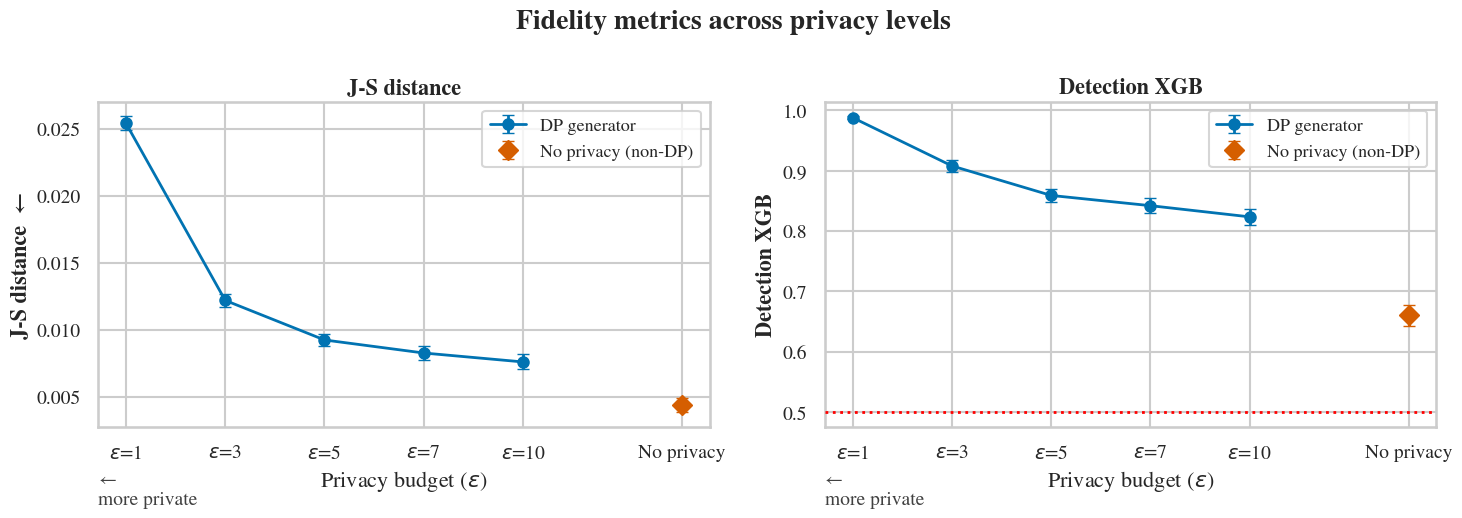

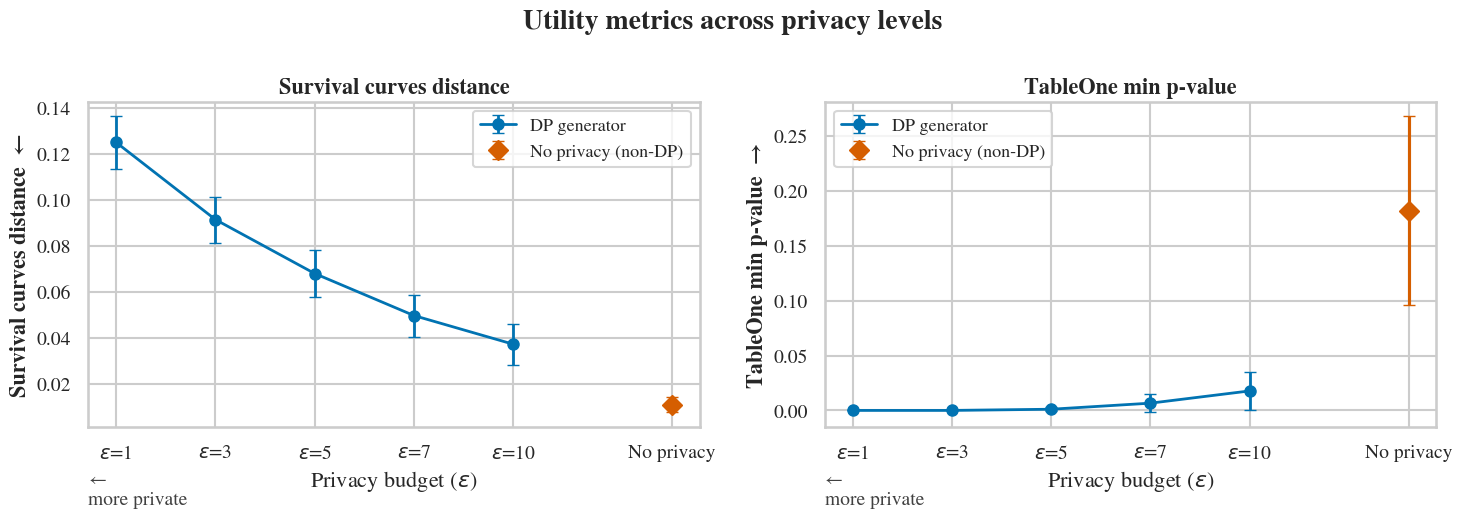

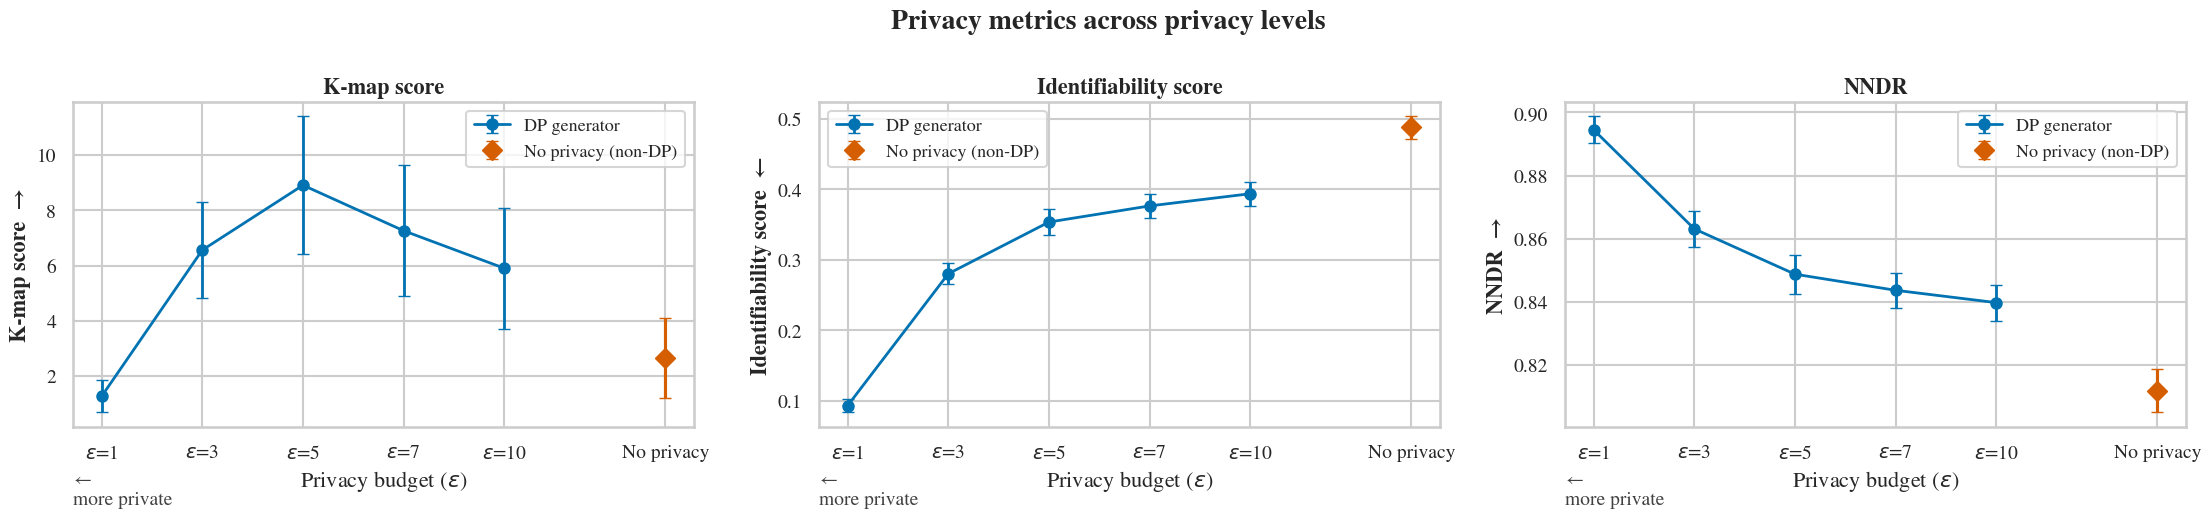

In [24]:
import importlib
importlib.reload(visualization)
from visualization import visualize_perf_vs_privacy

dict_metrics_fidelity = {"Fidelity": [["J-S distance", "min"], ["Detection XGB", 0.5]]}
dict_metrics_utility = {"Utility": [["Survival curves distance", "min"], ["TableOne min p-value", "max"]]}
dict_metrics_privacy = {"Privacy": [["K-map score", "max"], ["Identifiability score", "min"], ["NNDR", "max"]]}

fig = visualize_perf_vs_privacy(score_df_complete, dict_metrics_fidelity, ncols=2,
                          suptitle="Fidelity metrics across privacy levels")
fig = visualize_perf_vs_privacy(score_df_complete, dict_metrics_utility, ncols=2,
                          suptitle="Utility metrics across privacy levels")
fig = visualize_perf_vs_privacy(score_df_complete, dict_metrics_privacy, ncols=3,
                          suptitle="Privacy metrics across privacy levels")

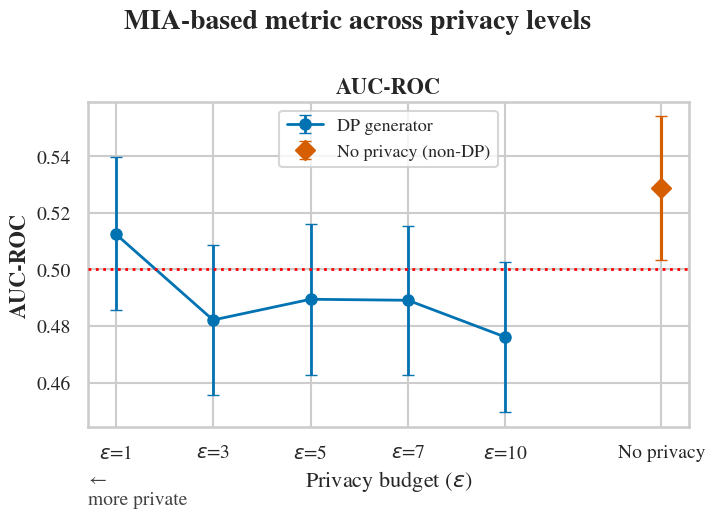

In [29]:
fig = visualize_perf_vs_privacy(mia_scores_df, {"Privacy": [["AUC-ROC", 0.5]]}, ncols=1,
                                suptitle="MIA-based metric across privacy levels")